
## NIO initial Points Density maps


In [1]:

# ============================================================
# Lorenz NIO Visual Discovery Paper
#
# Step 1 : Load NIO Results
# Step 2 : Summary Statistics
# Step 3 : 3D State Space Plot
# Step 4 : Projection Plots
# Step 5 : Sensitivity Density Maps
#
# Assumes:
#   nio_optimized_200_max.csv
#   nio_optimized_200_minimize.csv
#
# Uses:
#   900-step horizon only
#
# Ricardo Calix
# ============================================================


In [2]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from scipy.stats import gaussian_kde


In [3]:

# ============================================================
# CONFIGURATION
# ============================================================

## MAX_FILE = "nio_optimized_200_max.csv"
## MIN_FILE = "nio_optimized_200_minimize.csv"

MAX_FILE = "nio_optimized_200_max.csv"


###########################################

random_flag = False        ## Change Only this


if random_flag:
    MIN_FILE    = "random_points.csv"
    name_output = "Random"
else:
    MIN_FILE    = "nio_optimized_200_min.csv"
    name_output = "Min"


###########################################

HORIZON = 900


In [4]:

# ============================================================
# LOAD DATA
# ============================================================

max_df = pd.read_csv(MAX_FILE)
min_df = pd.read_csv(MIN_FILE)


In [5]:

max_df


,Time_steps,point_id,x0,y0,z0
0,300,0,4.334419,9.861786,13.155937
1,300,1,19.695328,0.779478,9.954550
2,300,2,17.409600,0.479961,17.064210
3,300,3,-13.649555,-11.529343,25.880936
4,300,4,-17.842530,-2.126389,24.121515
...,...,...,...,...,...
3995,1300,995,-17.978146,-24.966349,45.860374
3996,1300,996,9.016561,-9.979977,45.979233
3997,1300,997,-9.817795,21.351670,28.764898
3998,1300,998,11.516464,-19.466331,38.763220


In [6]:

min_df


,Time_steps,point_id,x0,y0,z0
0,300,0,-16.866148,7.687355,44.039280
1,300,1,-15.959354,11.692524,40.677410
2,300,2,-18.840310,9.322880,13.501758
3,300,3,16.939450,14.055645,10.128780
4,300,4,-7.871334,-17.974750,40.722477
...,...,...,...,...,...
3995,1300,995,2.783924,9.075871,6.339331
3996,1300,996,14.241150,24.845749,40.504356
3997,1300,997,15.099567,-17.586386,18.250864
3998,1300,998,-16.977428,18.135452,47.161160


In [7]:

time_col = [c for c in max_df.columns if "time" in c.lower()][0]


In [8]:

time_col


'Time_steps'

In [9]:

max_data = max_df[max_df[time_col] == HORIZON].copy()



In [10]:

if random_flag == False:
    min_data = min_df[min_df[time_col] == HORIZON].copy()
else:
    min_data = min_df.copy()    




In [11]:

max_data


,Time_steps,point_id,x0,y0,z0
2000,900,0,5.537384,7.429584,17.617476
2001,900,1,15.820267,-28.928047,3.342888
2002,900,2,-14.631885,4.445206,46.085743
2003,900,3,5.562977,-11.697836,9.759507
2004,900,4,10.387220,-10.459404,42.008293
...,...,...,...,...,...
2995,900,995,-15.646301,-14.692164,9.030634
2996,900,996,1.320507,0.247578,33.008760
2997,900,997,15.422245,-24.831097,46.137160
2998,900,998,-5.499721,0.647278,44.645885


In [12]:

min_data


,Time_steps,point_id,x0,y0,z0
2000,900,0,-18.988825,-23.030502,31.280739
2001,900,1,-11.308835,-22.894430,18.293621
2002,900,2,-4.381627,-1.826294,7.003131
2003,900,3,-16.373875,-18.380540,14.244254
2004,900,4,-11.266871,-21.222012,14.816197
...,...,...,...,...,...
2995,900,995,-11.037484,0.764620,12.615928
2996,900,996,18.658176,17.698730,15.561515
2997,900,997,-15.390007,18.603573,17.452955
2998,900,998,-13.754414,-26.605196,32.172560


In [13]:

print("\nLoaded Data")
print("----------------------------")
print("Max-sensitive points :", len(max_data))
print("Min-sensitive points :", len(min_data))



Loaded Data
----------------------------
Max-sensitive points : 1000
Min-sensitive points : 1000




## SUMMARY STATISTICS


In [14]:

print("\n")
print("="*70)
print("SUMMARY STATISTICS")
print("="*70)




SUMMARY STATISTICS


In [15]:

def summarize(df, label):

    stats = pd.DataFrame({
        "Mean": df[["x0","y0","z0"]].mean(),
        "Std":  df[["x0","y0","z0"]].std(),
        "Min":  df[["x0","y0","z0"]].min(),
        "Max":  df[["x0","y0","z0"]].max()
    })

    print("\n")
    print(label)
    print("-"*50)
    print(stats)


In [16]:

summarize(max_data, "MAX-SENSITIVE")




MAX-SENSITIVE
--------------------------------------------------
         Mean        Std        Min        Max
x0   0.105192  11.816708 -19.773264  19.779350
y0  -0.091881  16.934206 -29.452640  29.630203
z0  24.849367  14.285935   0.730564  49.861233


In [17]:

summarize(min_data, "MIN-SENSITIVE")




MIN-SENSITIVE
--------------------------------------------------
         Mean        Std        Min        Max
x0   0.096613  10.832965 -19.816950  19.531230
y0   0.093976  16.134630 -28.895647  28.436073
z0  25.104175  13.908780   0.806614  49.739517




## 3D STATE SPACE


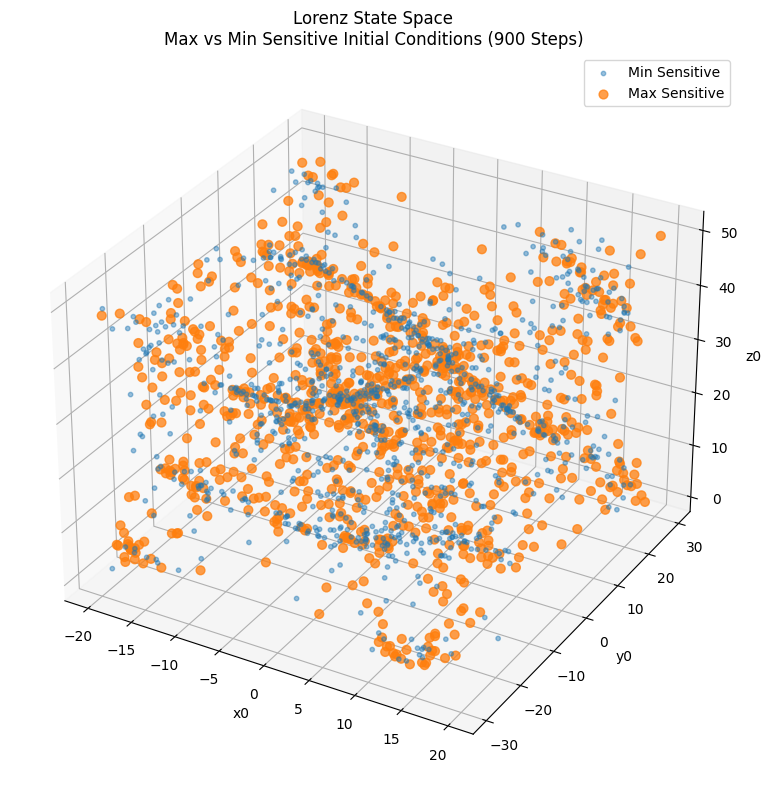

In [18]:

fig = plt.figure(figsize=(10,8))

ax = fig.add_subplot(
    111,
    projection='3d'
)


ax.scatter(
    min_data["x0"],
    min_data["y0"],
    min_data["z0"],
    s=10,
    alpha=0.45,
    label=name_output + " Sensitive"
)

ax.scatter(
    max_data["x0"],
    max_data["y0"],
    max_data["z0"],
    s=40,
    alpha=0.75,
    label="Max Sensitive"
)

ax.set_xlabel("x0")
ax.set_ylabel("y0")
ax.set_zlabel("z0")

ax.set_title(
    f"Lorenz State Space\nMax vs " + name_output + " Sensitive Initial Conditions (900 Steps)"
)

ax.legend()

plt.tight_layout()
plt.savefig(
    name_output + "_Figure1_3D_StateSpace.png",
    dpi=300
)

plt.show()





## PROJECTION PLOTS


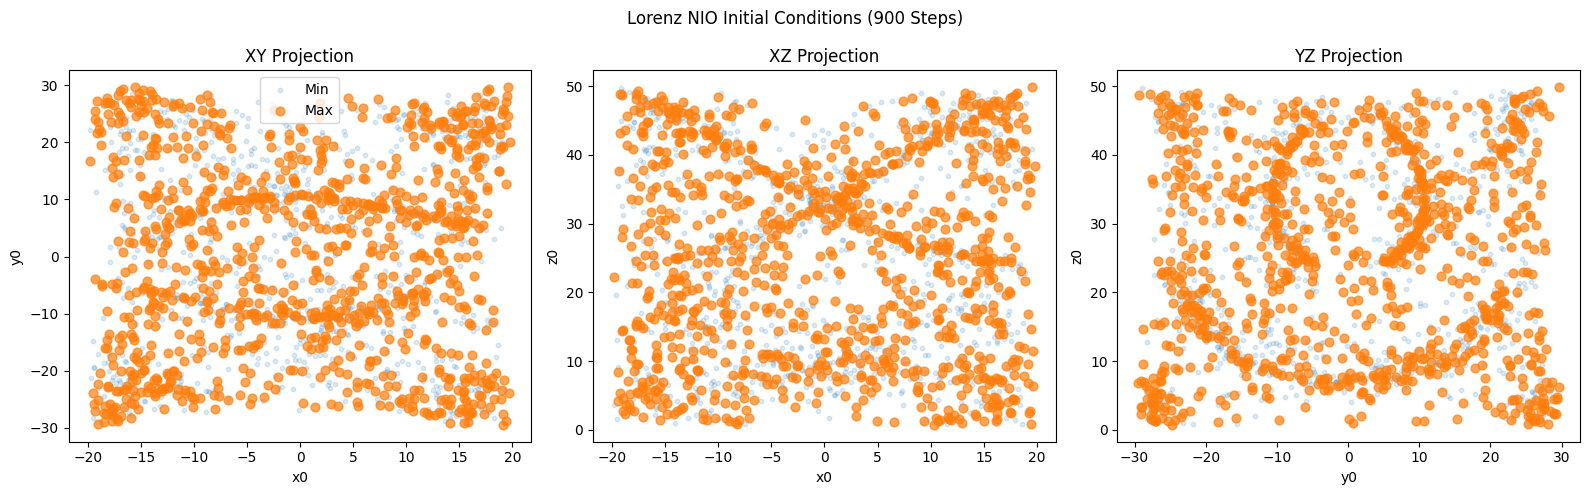

In [19]:


fig, axs = plt.subplots(
    1,
    3,
    figsize=(16,5)
)


# ------------------------------------------------------------
# XY
# ------------------------------------------------------------

axs[0].scatter(
    min_data["x0"],
    min_data["y0"],
    s=10,
    alpha=0.15,
    label=name_output + ""
)

axs[0].scatter(
    max_data["x0"],
    max_data["y0"],
    s=40,
    alpha=0.7,
    label="Max"
)

axs[0].set_title("XY Projection")
axs[0].set_xlabel("x0")
axs[0].set_ylabel("y0")

# ------------------------------------------------------------
# XZ
# ------------------------------------------------------------

axs[1].scatter(
    min_data["x0"],
    min_data["z0"],
    s=10,
    alpha=0.15
)

axs[1].scatter(
    max_data["x0"],
    max_data["z0"],
    s=40,
    alpha=0.7
)

axs[1].set_title("XZ Projection")
axs[1].set_xlabel("x0")
axs[1].set_ylabel("z0")

# ------------------------------------------------------------
# YZ
# ------------------------------------------------------------

axs[2].scatter(
    min_data["y0"],
    min_data["z0"],
    s=10,
    alpha=0.15
)

axs[2].scatter(
    max_data["y0"],
    max_data["z0"],
    s=40,
    alpha=0.7
)

axs[2].set_title("YZ Projection")
axs[2].set_xlabel("y0")
axs[2].set_ylabel("z0")


axs[0].legend()

plt.suptitle(
    f"Lorenz NIO Initial Conditions ({HORIZON} Steps)"
)

plt.tight_layout()

plt.savefig(
    name_output + "Figure2_ProjectionPlots.png",
    dpi=300
)

plt.show()




## SENSITIVITY DENSITY MAPS

* rho_max - rho_min



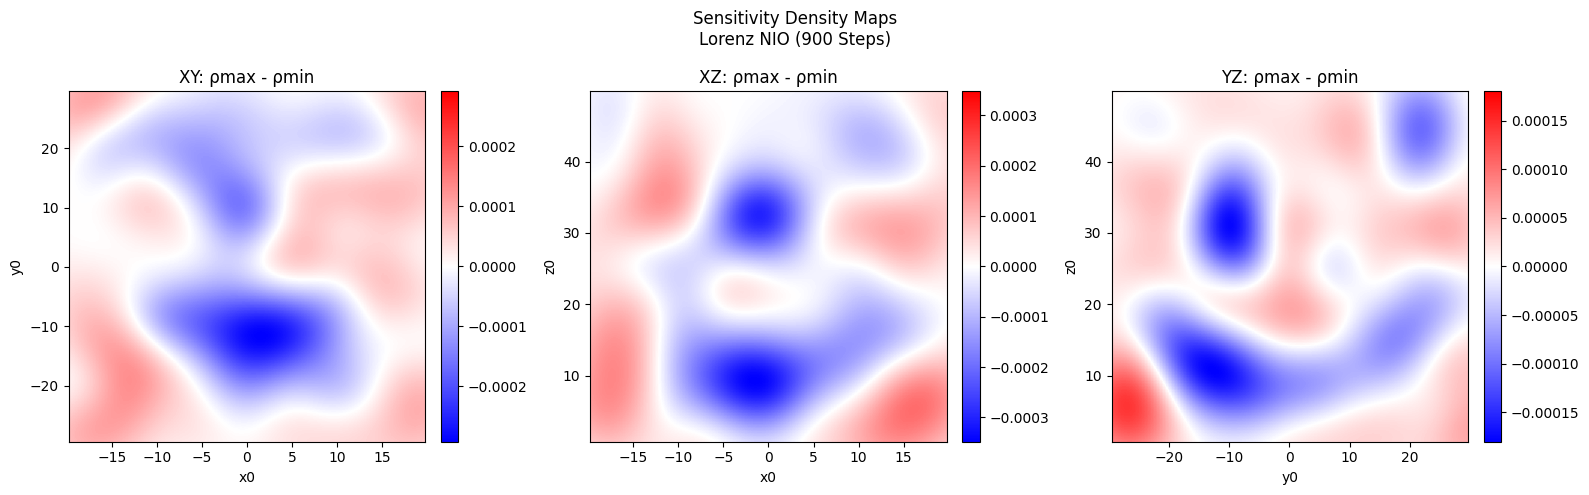

In [20]:

fig, axs = plt.subplots(
    1,
    3,
    figsize=(16,5)
)

pairs = [
    ("x0","y0","XY"),
    ("x0","z0","XZ"),
    ("y0","z0","YZ")
]


for ax, (a,b,title) in zip(axs,pairs):

    all_a = np.concatenate([
        max_data[a],
        min_data[a]
    ])

    all_b = np.concatenate([
        max_data[b],
        min_data[b]
    ])

    grid_a = np.linspace(
        all_a.min(),
        all_a.max(),
        120
    )

    grid_b = np.linspace(
        all_b.min(),
        all_b.max(),
        120
    )

    A,B = np.meshgrid(
        grid_a,
        grid_b
    )

    kde_max = gaussian_kde(
        np.vstack([
            max_data[a],
            max_data[b]
        ])
    )

    kde_min = gaussian_kde(
        np.vstack([
            min_data[a],
            min_data[b]
        ])
    )

    rho_max = kde_max(
        np.vstack([
            A.ravel(),
            B.ravel()
        ])
    ).reshape(A.shape)

    rho_min = kde_min(
        np.vstack([
            A.ravel(),
            B.ravel()
        ])
    ).reshape(A.shape)

    density_difference = (
        rho_max - rho_min
    )

    vmax = np.abs(
        density_difference
    ).max()

    image = ax.imshow(
        density_difference,
        origin="lower",
        extent=[
            grid_a.min(),
            grid_a.max(),
            grid_b.min(),
            grid_b.max()
        ],
        aspect="auto",
        cmap="bwr",
        vmin=-vmax,
        vmax=vmax
    )

    ax.set_title(
        f"{title}: ρmax - ρmin"
    )

    ax.set_xlabel(a)
    ax.set_ylabel(b)

    plt.colorbar(
        image,
        ax=ax,
        fraction=0.046,
        pad=0.04
    )

 
plt.suptitle(
    f"Sensitivity Density Maps\nLorenz NIO ({HORIZON} Steps)"
)

plt.tight_layout()

plt.savefig(
    name_output + "Figure3_DensityMaps.png",
    dpi=300
)

plt.show()




## Broken up approach of the previous 




## CREATE XY GRID

* We first create a common coordinate system that both populations will use


In [21]:



x_max = max_data["x0"]
y_max = max_data["y0"]

x_min = min_data["x0"]
y_min = min_data["y0"]

xmin = min(x_max.min(), x_min.min())
xmax = max(x_max.max(), x_min.max())

ymin = min(y_max.min(), y_min.min())
ymax = max(y_max.max(), y_min.max())

grid_x = np.linspace(xmin, xmax, 120)
grid_y = np.linspace(ymin, ymax, 120)

X_xy, Y_xy = np.meshgrid(
    grid_x,
    grid_y
)


In [22]:

grid_x


array([-19.81695   , -19.48420798, -19.15146597, -18.81872395,
       -18.48598193, -18.15323992, -17.8204979 , -17.48775588,
       -17.15501387, -16.82227185, -16.48952983, -16.15678782,
       -15.8240458 , -15.49130378, -15.15856176, -14.82581975,
       -14.49307773, -14.16033571, -13.8275937 , -13.49485168,
       -13.16210966, -12.82936765, -12.49662563, -12.16388361,
       -11.8311416 , -11.49839958, -11.16565756, -10.83291555,
       -10.50017353, -10.16743151,  -9.8346895 ,  -9.50194748,
        -9.16920546,  -8.83646345,  -8.50372143,  -8.17097941,
        -7.83823739,  -7.50549538,  -7.17275336,  -6.84001134,
        -6.50726933,  -6.17452731,  -5.84178529,  -5.50904328,
        -5.17630126,  -4.84355924,  -4.51081723,  -4.17807521,
        -3.84533319,  -3.51259118,  -3.17984916,  -2.84710714,
        -2.51436513,  -2.18162311,  -1.84888109,  -1.51613908,
        -1.18339706,  -0.85065504,  -0.51791303,  -0.18517101,
         0.14757101,   0.48031303,   0.81305504,   1.14

In [23]:

grid_y


array([-29.45264   , -28.95614552, -28.45965104, -27.96315656,
       -27.46666208, -26.97016761, -26.47367313, -25.97717865,
       -25.48068417, -24.98418969, -24.48769521, -23.99120073,
       -23.49470625, -22.99821177, -22.50171729, -22.00522282,
       -21.50872834, -21.01223386, -20.51573938, -20.0192449 ,
       -19.52275042, -19.02625594, -18.52976146, -18.03326698,
       -17.5367725 , -17.04027803, -16.54378355, -16.04728907,
       -15.55079459, -15.05430011, -14.55780563, -14.06131115,
       -13.56481667, -13.06832219, -12.57182771, -12.07533324,
       -11.57883876, -11.08234428, -10.5858498 , -10.08935532,
        -9.59286084,  -9.09636636,  -8.59987188,  -8.1033774 ,
        -7.60688292,  -7.11038845,  -6.61389397,  -6.11739949,
        -5.62090501,  -5.12441053,  -4.62791605,  -4.13142157,
        -3.63492709,  -3.13843261,  -2.64193813,  -2.14544366,
        -1.64894918,  -1.1524547 ,  -0.65596022,  -0.15946574,
         0.33702874,   0.83352322,   1.3300177 ,   1.82


## KDE for Max-Sensitive Points


In [24]:



kde_max_xy = gaussian_kde(
    np.vstack([
        x_max,
        y_max
    ])
)

rho_max_xy = kde_max_xy(
    np.vstack([
        X_xy.ravel(),
        Y_xy.ravel()
    ])
).reshape(X_xy.shape)


In [25]:

kde_max_xy


In [26]:

rho_max_xy


array([[0.00021486, 0.00022793, 0.00024034, ..., 0.00020489, 0.00019127,
        0.00017755],
       [0.0002286 , 0.00024276, 0.00025626, ..., 0.00021945, 0.00020491,
        0.00019026],
       [0.00024173, 0.00025698, 0.00027157, ..., 0.00023354, 0.00021812,
        0.00020257],
       ...,
       [0.00019488, 0.00020965, 0.00022424, ..., 0.00025565, 0.00024325,
        0.00023016],
       [0.00018439, 0.00019847, 0.00021239, ..., 0.00023778, 0.00022643,
        0.0002144 ],
       [0.0001733 , 0.00018663, 0.00019983, ..., 0.00021983, 0.00020949,
        0.00019853]])


## KDE for Min-Sensitive Points


In [27]:



kde_min_xy = gaussian_kde(
    np.vstack([
        x_min,
        y_min
    ])
)

rho_min_xy = kde_min_xy(
    np.vstack([
        X_xy.ravel(),
        Y_xy.ravel()
    ])
).reshape(X_xy.shape)


In [28]:

# ==================================================
# 
# DIFFERENCE MAP
# ==================================================

rho_diff_xy = (
    rho_max_xy - rho_min_xy
)


In [29]:

rho_diff_xy


array([[7.69732177e-05, 8.05794306e-05, 8.39119938e-05, ...,
        6.74485454e-05, 6.61646170e-05, 6.44800596e-05],
       [7.80489525e-05, 8.17911441e-05, 8.52808076e-05, ...,
        7.12827718e-05, 7.00201688e-05, 6.83199693e-05],
       [7.83854396e-05, 8.22413552e-05, 8.58722618e-05, ...,
        7.49278352e-05, 7.36979340e-05, 7.19929670e-05],
       ...,
       [8.82734378e-05, 9.19585722e-05, 9.51403395e-05, ...,
        7.90626560e-05, 8.00652201e-05, 8.03630820e-05],
       [8.69056935e-05, 9.08198589e-05, 9.42705900e-05, ...,
        7.76961556e-05, 7.84918677e-05, 7.86125727e-05],
       [8.47718517e-05, 8.88481286e-05, 9.25019807e-05, ...,
        7.57325111e-05, 7.63401353e-05, 7.63053817e-05]])

In [30]:

# ==================================================

# XZ PROJECTION
# ==================================================

x_max = max_data["x0"]
z_max = max_data["z0"]

x_min = min_data["x0"]
z_min = min_data["z0"]

xmin = min(x_max.min(), x_min.min())
xmax = max(x_max.max(), x_min.max())

zmin = min(z_max.min(), z_min.min())
zmax = max(z_max.max(), z_min.max())

grid_x = np.linspace(xmin, xmax, 120)
grid_z = np.linspace(zmin, zmax, 120)

X_xz, Z_xz = np.meshgrid(
    grid_x,
    grid_z
)

kde_max_xz = gaussian_kde(
    np.vstack([
        x_max,
        z_max
    ])
)

rho_max_xz = kde_max_xz(
    np.vstack([
        X_xz.ravel(),
        Z_xz.ravel()
    ])
).reshape(X_xz.shape)

kde_min_xz = gaussian_kde(
    np.vstack([
        x_min,
        z_min
    ])
)

rho_min_xz = kde_min_xz(
    np.vstack([
        X_xz.ravel(),
        Z_xz.ravel()
    ])
).reshape(X_xz.shape)

rho_diff_xz = (
    rho_max_xz -
    rho_min_xz
)


In [31]:

# ==================================================
# YZ PROJECTION
# ==================================================

y_max = max_data["y0"]
z_max = max_data["z0"]

y_min = min_data["y0"]
z_min = min_data["z0"]

ymin = min(y_max.min(), y_min.min())
ymax = max(y_max.max(), y_min.max())

zmin = min(z_max.min(), z_min.min())
zmax = max(z_max.max(), z_min.max())

grid_y = np.linspace(ymin, ymax, 120)
grid_z = np.linspace(zmin, zmax, 120)

Y_yz, Z_yz = np.meshgrid(
    grid_y,
    grid_z
)

kde_max_yz = gaussian_kde(
    np.vstack([
        y_max,
        z_max
    ])
)

rho_max_yz = kde_max_yz(
    np.vstack([
        Y_yz.ravel(),
        Z_yz.ravel()
    ])
).reshape(Y_yz.shape)

kde_min_yz = gaussian_kde(
    np.vstack([
        y_min,
        z_min
    ])
)

rho_min_yz = kde_min_yz(
    np.vstack([
        Y_yz.ravel(),
        Z_yz.ravel()
    ])
).reshape(Y_yz.shape)

rho_diff_yz = (
    rho_max_yz -
    rho_min_yz
)


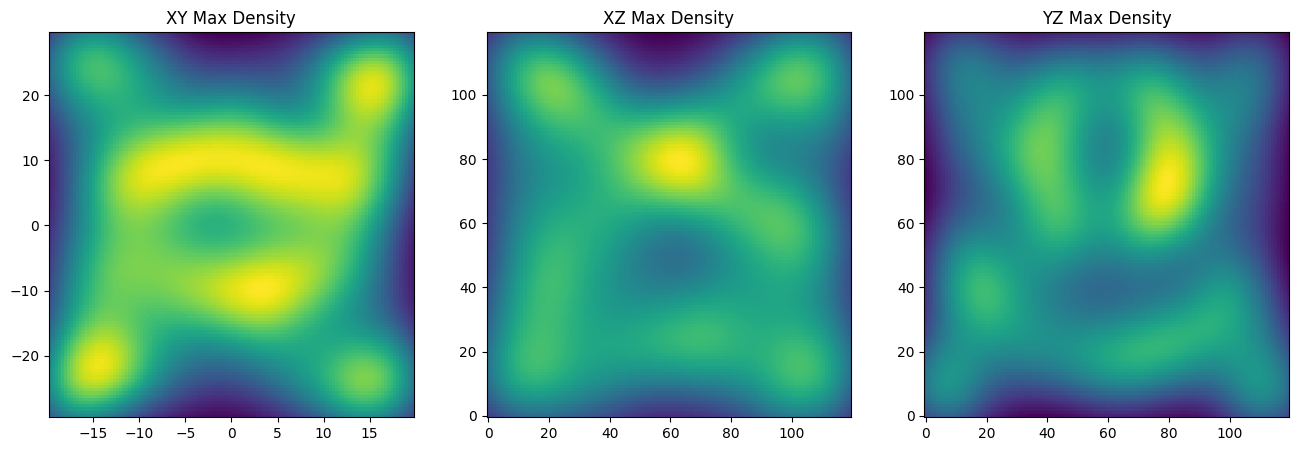

In [32]:

## Where does NIO find highly sensitive initial conditions?

fig, axs = plt.subplots(1,3,figsize=(16,5))

axs[0].imshow(
    rho_max_xy,
    origin="lower",
    extent=[
        grid_x.min(),
        grid_x.max(),
        grid_y.min(),
        grid_y.max()
    ],
    aspect="auto"
)

axs[0].set_title("XY Max Density")

axs[1].imshow(
    rho_max_xz,
    origin="lower",
    aspect="auto"
)

axs[1].set_title("XZ Max Density")

axs[2].imshow(
    rho_max_yz,
    origin="lower",
    aspect="auto"
)

axs[2].set_title("YZ Max Density")

plt.show()


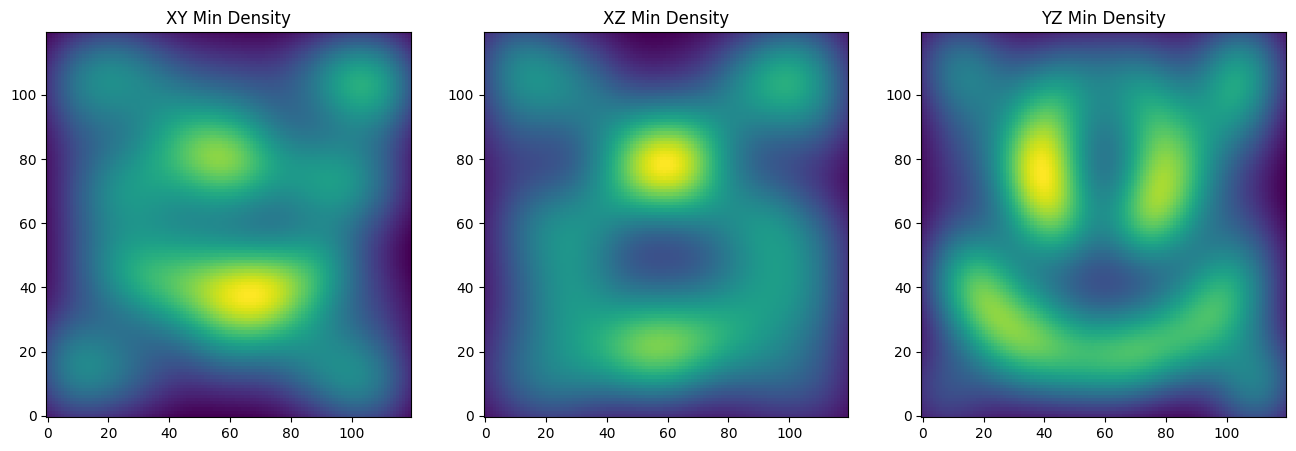

In [33]:

## Where does NIO find insensitive initial conditions?

fig, axs = plt.subplots(1,3,figsize=(16,5))

axs[0].imshow(rho_min_xy,origin="lower",aspect="auto")
axs[0].set_title("XY " + name_output + " Density")

axs[1].imshow(rho_min_xz,origin="lower",aspect="auto")
axs[1].set_title("XZ " + name_output + " Density")

axs[2].imshow(rho_min_yz,origin="lower",aspect="auto")
axs[2].set_title("YZ " + name_output + " Density")

plt.show()


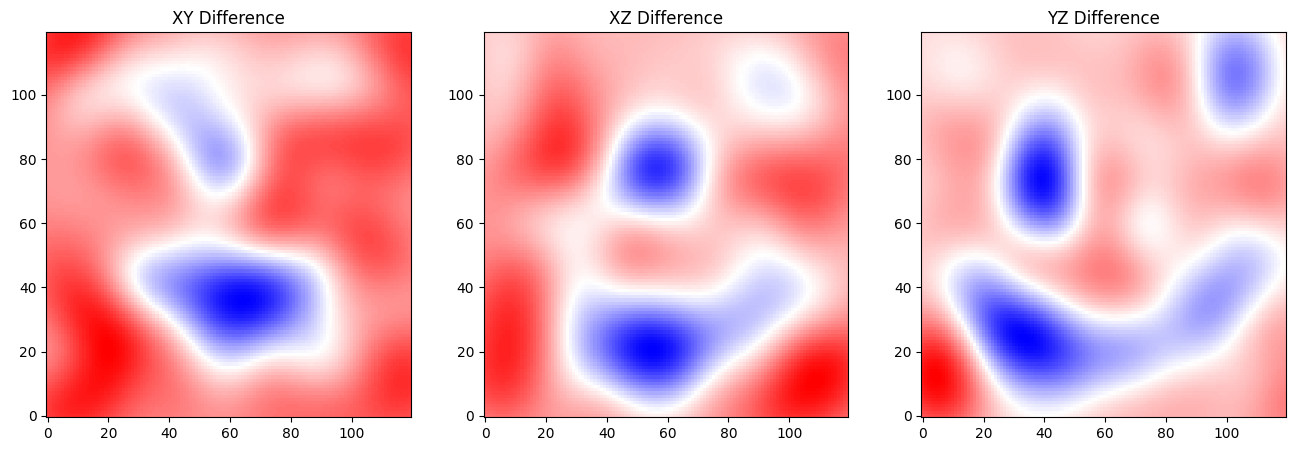

In [34]:

## Where do max-sensitive and min-sensitive regions differ?

fig, axs = plt.subplots(1,3,figsize=(16,5))

axs[0].imshow(
    rho_diff_xy,
    origin="lower",
    cmap="bwr",
    aspect="auto"
)

axs[0].set_title("XY Difference")

axs[1].imshow(
    rho_diff_xz,
    origin="lower",
    cmap="bwr",
    aspect="auto"
)

axs[1].set_title("XZ Difference")

axs[2].imshow(
    rho_diff_yz,
    origin="lower",
    cmap="bwr",
    aspect="auto"
)

axs[2].set_title("YZ Difference")

plt.show()



## More simplification 


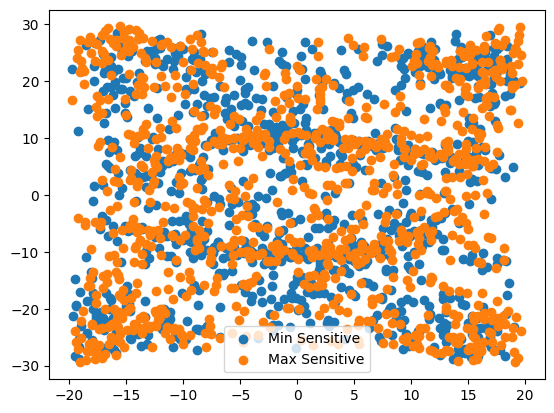

In [35]:


plt.scatter(
    min_data["x0"],
    min_data["y0"],
    label=name_output + " Sensitive"
)

plt.scatter(
    max_data["x0"],
    max_data["y0"],
    label="Max Sensitive"
)


plt.legend()
plt.show()


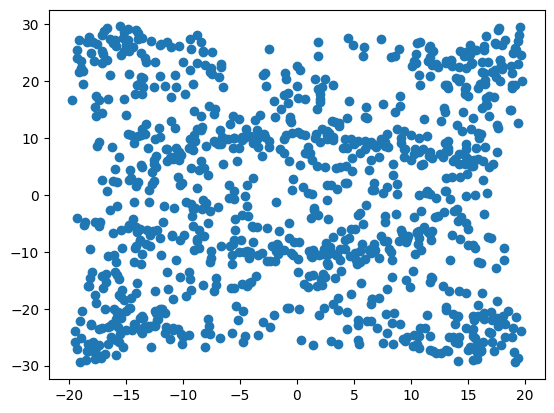

In [36]:

x = max_data["x0"]
y = max_data["y0"]

plt.scatter(x,y)
plt.show()


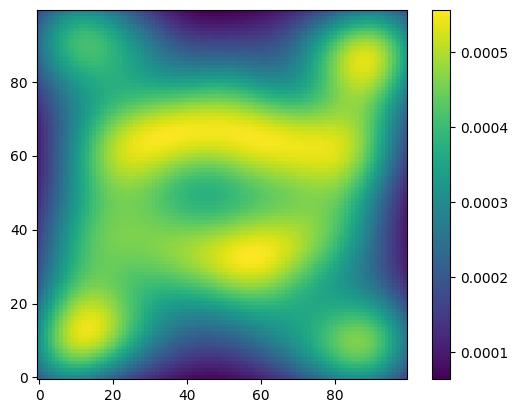

In [37]:

kde = gaussian_kde(
    np.vstack([x,y])
)

grid_x = np.linspace(x.min(),x.max(),100)
grid_y = np.linspace(y.min(),y.max(),100)

X,Y = np.meshgrid(
    grid_x,
    grid_y
)

rho = kde(
    np.vstack([
        X.ravel(),
        Y.ravel()
    ])
)

rho = rho.reshape(
    X.shape
)

plt.imshow(
    rho,
    origin="lower"
)

plt.colorbar()
plt.show()



## Super Simple Again


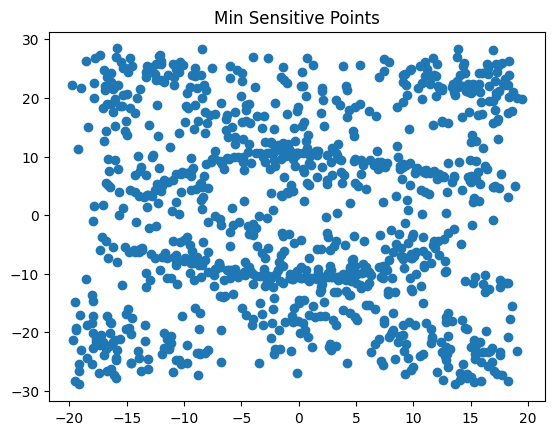

In [38]:

x = min_data["x0"]
y = min_data["y0"]

plt.scatter(x,y)
plt.title(name_output + " Sensitive Points")
plt.show()


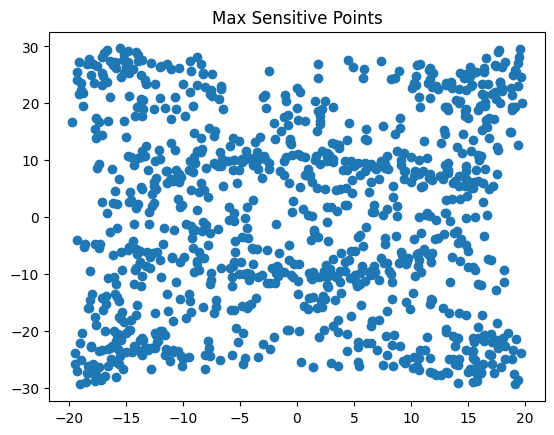

In [39]:

x = max_data["x0"]
y = max_data["y0"]

plt.scatter(x,y)
plt.title("Max Sensitive Points")
plt.show()


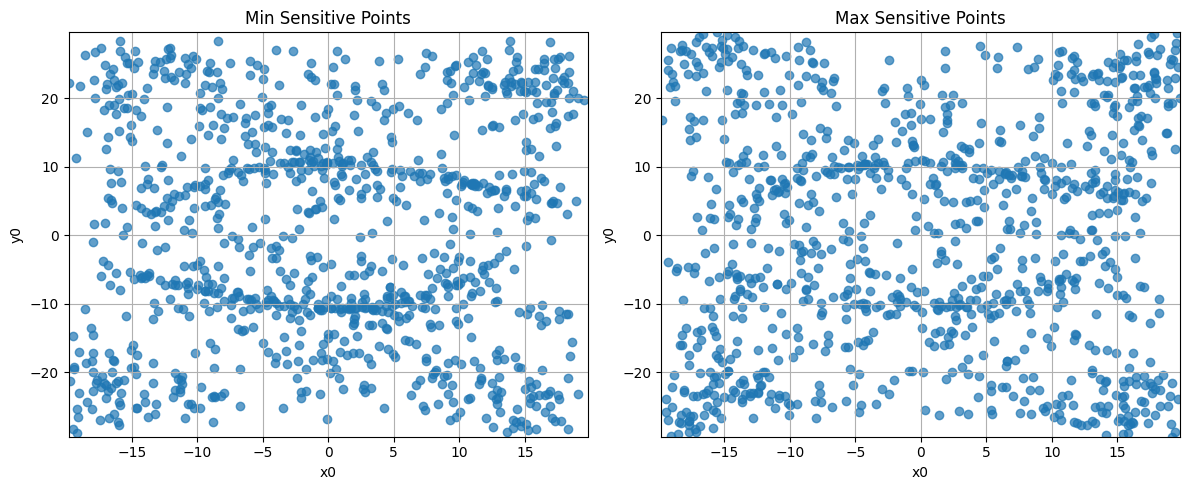

In [40]:

import matplotlib.pyplot as plt

# ---------------------------------------
# Side-by-side comparison
# ---------------------------------------

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Common axis limits
xmin = min(min_data["x0"].min(), max_data["x0"].min())
xmax = max(min_data["x0"].max(), max_data["x0"].max())

ymin = min(min_data["y0"].min(), max_data["y0"].min())
ymax = max(min_data["y0"].max(), max_data["y0"].max())

# ---------------------------------------
# Min-sensitive points
# ---------------------------------------

ax[0].scatter(
    min_data["x0"],
    min_data["y0"],
    alpha=0.7
)

ax[0].set_title(name_output + " Sensitive Points")
ax[0].set_xlabel("x0")
ax[0].set_ylabel("y0")
ax[0].set_xlim(xmin, xmax)
ax[0].set_ylim(ymin, ymax)
ax[0].grid(True)

# ---------------------------------------
# Max-sensitive points
# ---------------------------------------

ax[1].scatter(
    max_data["x0"],
    max_data["y0"],
    alpha=0.7
)

ax[1].set_title("Max Sensitive Points")
ax[1].set_xlabel("x0")
ax[1].set_ylabel("y0")
ax[1].set_xlim(xmin, xmax)
ax[1].set_ylim(ymin, ymax)
ax[1].grid(True)

plt.tight_layout()
plt.show()


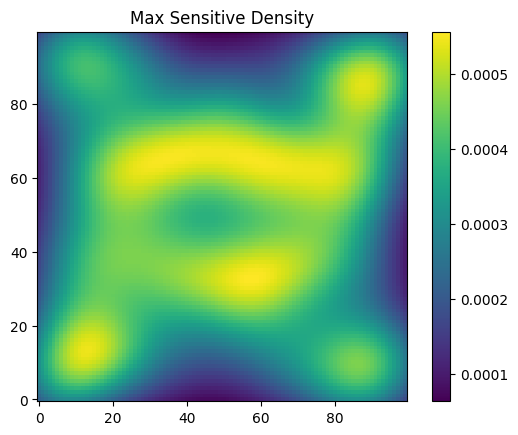

In [41]:

x = max_data["x0"]
y = max_data["y0"]

kde = gaussian_kde(
    np.vstack([x,y])
)

X,Y = np.meshgrid(
    np.linspace(x.min(),x.max(),100),
    np.linspace(y.min(),y.max(),100)
)

rho_max = kde(
    np.vstack([
        X.ravel(),
        Y.ravel()
    ])
).reshape(X.shape)

plt.imshow(
    rho_max,
    origin="lower"
)

plt.colorbar()
plt.title("Max Sensitive Density")
plt.show()


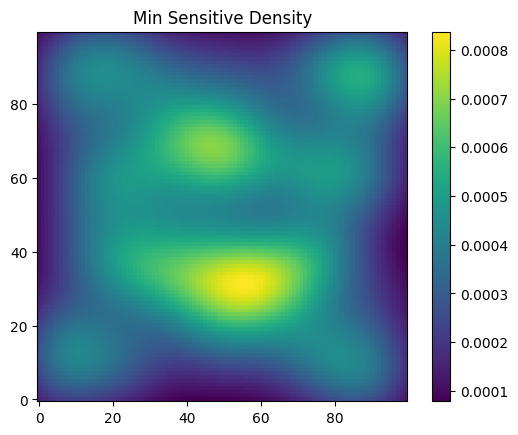

In [42]:

x = min_data["x0"]
y = min_data["y0"]

kde = gaussian_kde(
    np.vstack([x,y])
)

X,Y = np.meshgrid(
    np.linspace(x.min(),x.max(),100),
    np.linspace(y.min(),y.max(),100)
)

rho_min = kde(
    np.vstack([
        X.ravel(),
        Y.ravel()
    ])
).reshape(X.shape)

plt.imshow(
    rho_min,
    origin="lower"
)

plt.colorbar()
plt.title( name_output + " Sensitive Density")
plt.show()


In [43]:

np.vstack([x,y])


array([[-18.988825 , -11.308835 ,  -4.381627 , ..., -15.390007 ,
        -13.754414 ,  -7.6997128],
       [-23.030502 , -22.89443  ,  -1.826294 , ...,  18.603573 ,
        -26.605196 ,  17.04406  ]])

In [44]:

rho_diff = rho_max - rho_min


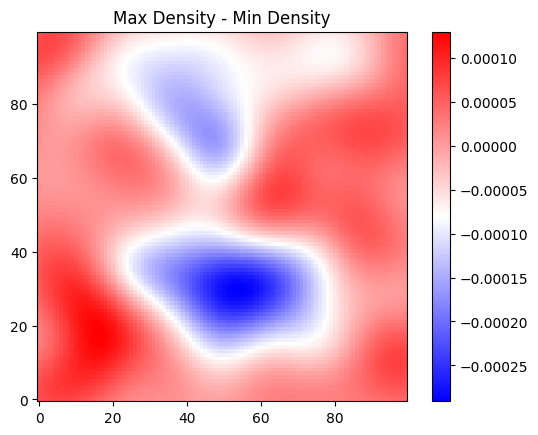

In [45]:

plt.imshow(
    rho_diff,
    origin="lower",
    cmap="bwr"
)

plt.colorbar()
plt.title("Max Density - " + name_output + " Density")
plt.show()



## Generate case 3 - Random data


In [ ]:




# ==================================================
# RANDOM BASELINE
# ==================================================

import pandas as pd
import numpy as np

N = 1000

random_x = np.random.uniform(
    -20,
    20,
    N
)

random_y = np.random.uniform(
    -30,
    30,
    N
)

random_z = np.random.uniform(
    0,
    50,
    N
)

random_df = pd.DataFrame({
    "Time_steps": 900,
    "x0"        : random_x,
    "y0"        : random_y,
    "z0"        : random_z
})

random_df.to_csv(
    "random_points.csv",
    index=False
)

print(random_df.head())

print()
print("Saved:")
print("random_points.csv")
print("Number of points:", len(random_df))






